# VAE — EMNIST
**Project: Latent Diffusion on EMNIST**

This notebook trains a VAE with separate Encoder and Decoder.
At the end, it saves `encoder.ckpt` and `decoder.ckpt` for use in the Diffusion/Flow stage.

> Run on: Runtime → Change Runtime Type → T4 GPU

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## 2. Hyperparameters

In [ ]:
# ── Hyperparameters ─────────────────────────────────────────────
LATENT_DIM        = 64           # dimensionality of the latent space z
BATCH_SIZE        = 256
EPOCHS            = 1024
LEARNING_RATE     = 1e-3
USE_DIFF_SIGMA_E  = True         # True = different sigma per dimension
RECONSTRUCTION    = 'Bernoulli'  # 'Gaussian' | 'Laplacian' | 'Bernoulli'
EMNIST_SPLIT      = 'byclass'    # 62 classes: digits + uppercase + lowercase
# ────────────────────────────────────────────────────────────────

# ── Checkpointing ─────────────────────────────────────────────
CKPT_DIR        = 'notebooks/training_checkpoints'  # where to save .ckpt files
CHECKPOINT_EVERY = 5     
KEEP_LAST       = 5                            # save a checkpoint every N epochs
os.makedirs(CKPT_DIR, exist_ok=True)
# ────────────────────────────────────────────────────────────────


## 3. Shape helpers

In [3]:
def image_to_vec(x):
    """(B,1,28,28) -> (B,784)"""
    return x.view(x.size(0), -1)

def vec_to_image(x):
    """(784,) -> (28,28)  for a single example"""
    return x.view(28, 28)

class Unflatten(nn.Module):
    """(B,3136) -> (B,64,7,7)"""
    def forward(self, x):
        return x.view(-1, 64, 7, 7)

class ReshapeToImage(nn.Module):
    """(B,784) -> (B,1,28,28)"""
    def forward(self, x):
        return x.view(-1, 1, 28, 28)

## 4. Architecture

### Encoder
Takes `x` (784,) and returns `(mu, logvar)` of dimension `LATENT_DIM`.
```
x (784) -> reshape (1,28,28)
         -> Conv2d(1->32, k=4, s=2, p=1)  -> (32,14,14)
         -> Conv2d(32->64, k=4, s=2, p=1) -> (64,7,7)
         -> Flatten -> (3136)
         -> Linear -> mu (LATENT_DIM)
         -> Linear -> logvar (LATENT_DIM or 1)
```

### Decoder
Takes `z` (LATENT_DIM,) and returns `x_hat` (784,).
```
z (LATENT_DIM) -> Linear -> (3136) -> reshape (64,7,7)
               -> ConvTranspose2d(64->32, k=4, s=2, p=1) -> (32,14,14)
               -> ConvTranspose2d(32->1,  k=4, s=2, p=1) -> (1,28,28)
               -> Sigmoid -> Flatten -> x_hat (784)
```

In [4]:
class Encoder(nn.Module):
    """
    VAE Encoder.
    Input  : x of shape (B, 784)
    Output : mu (B, latent_dim) and logvar (B, latent_dim) or (B, 1)
    """
    def __init__(self, latent_dim, use_diff_sigma_E):
        super().__init__()
        self.conv = nn.Sequential(
            ReshapeToImage(),                                       # -> (B,1,28,28)
            nn.Conv2d(1,  32, kernel_size=4, stride=2, padding=1),  # -> (B,32,14,14)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> (B,64,7,7)
            nn.ReLU(),
            nn.Flatten(),                                           # -> (B,3136)
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        # use_diff_sigma_E=True  -> different sigma per dimension (more expressive)
        # use_diff_sigma_E=False -> shared (scalar) sigma
        logvar_out = latent_dim if use_diff_sigma_E else 1
        self.fc_logvar = nn.Linear(64 * 7 * 7, logvar_out)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)  # returns (mu, logvar)


class Decoder(nn.Module):
    """
    VAE Decoder.
    Input  : z of shape (B, latent_dim)
    Output : x_hat of shape (B, 784), values in [0,1]
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
            Unflatten(),                                                     # -> (B,64,7,7)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # -> (B,32,14,14)
            nn.ReLU(),
            nn.ConvTranspose2d(32,  1, kernel_size=4, stride=2, padding=1),  # -> (B,1,28,28)
            nn.Sigmoid(),
            nn.Flatten(),                                                    # -> (B,784)
        )

    def forward(self, z):
        return self.net(z)

## 5. VAE (training wrapper)

In [5]:
class VAE(nn.Module):
    """
    Combines Encoder and Decoder.
    The forward method computes the ELBO loss:
        loss = reconstruction_error + KL_divergence
    """
    def __init__(self, latent_dim, use_diff_sigma_E, reconstruction_type):
        super().__init__()
        self.latent_dim          = latent_dim
        self.use_diff_sigma_E    = use_diff_sigma_E
        self.reconstruction_type = reconstruction_type

        self.encoder = Encoder(latent_dim, use_diff_sigma_E)
        self.decoder = Decoder(latent_dim)

    # ── Reparameterization trick ─────────────────────────────────
    def sample_z(self, mu, logvar):
        """
        Sample z ~ N(mu, sigma^2) in a differentiable way.
        z = mu + sigma * epsilon,  epsilon ~ N(0,I)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(mu)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        var = logvar.exp()
        z   = self.sample_z(mu, logvar)
        x_hat = self.decoder(z)

        # — Reconstruction error (negative log-likelihood) —
        if self.reconstruction_type == 'Gaussian':
            # p(x|z) = N(x_hat, I)  ->  MSE
            recon = 0.5 * ((x_hat - x) ** 2).sum(dim=1).mean()

        elif self.reconstruction_type == 'Laplacian':
            # p(x|z) = Laplace(x_hat, 1)  ->  MAE
            recon = torch.abs(x_hat - x).sum(dim=1).mean()

        elif self.reconstruction_type == 'Bernoulli':
            # p(x|z) = Bernoulli(x_hat)  ->  BCE
            recon = -(
                (1e-4 + x_hat).log() * x +
                (1e-4 + 1 - x_hat).log() * (1 - x)
            ).sum(dim=1).mean()

        # — KL divergence: D_KL( q(z|x) || N(0,I) ) —
        if self.use_diff_sigma_E:
            # different sigma per dimension
            kl = 0.5 * (mu ** 2 + var - logvar - 1).sum(dim=1).mean()
        else:
            # shared scalar sigma
            kl  = 0.5 * (mu ** 2).sum(dim=1).mean()
            kl += 0.5 * self.latent_dim * (var - logvar - 1).mean()

        return recon + kl

    # ── Helper methods ───────────────────────────────────────────
    def encode(self, x):
        """Returns only mu (no noise) — used in the Diffusion stage."""
        mu, _ = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)

## 6. EMNIST dataset

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.EMNIST(
    root='data',
    split=EMNIST_SPLIT,   # 'byclass': 62 classes (0-9, A-Z, a-z)
    train=True,
    transform=transform,
    download=True,
)
test_dataset = datasets.EMNIST(
    root='data',
    split=EMNIST_SPLIT,
    train=False,
    transform=transform,
    download=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train  : {len(train_dataset):,} images')
print(f'Test   : {len(test_dataset):,} images')
print(f'Classes: {len(train_dataset.classes)}')

Train  : 697,932 images
Test   : 116,323 images
Classes: 62


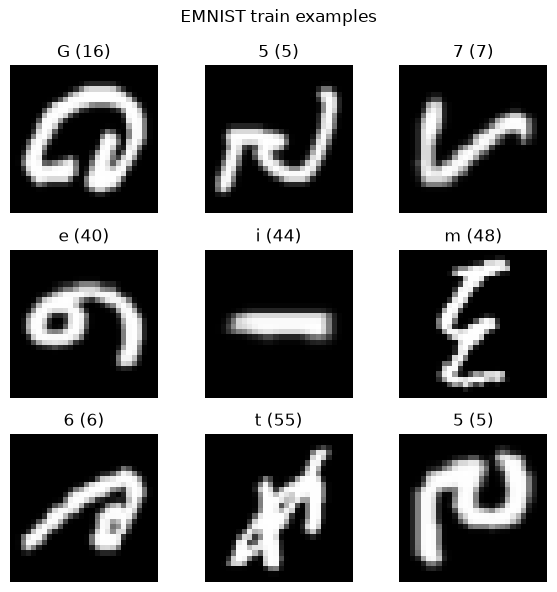

In [7]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze(0)
    label = train_dataset.classes[labels[i].item()]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{label} ({labels[i].item()})')
    ax.axis('off')

plt.suptitle('EMNIST train examples')
plt.tight_layout()
plt.show()

## 7. Training and evaluation functions

In [8]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, _ in loader:
        x = image_to_vec(images.to(device))
        optimizer.zero_grad()
        loss = model(x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    # loss is already the per-sample mean within each batch,
    # so average over the number of batches (not over the dataset size)
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    for images, _ in loader:
        x = image_to_vec(images.to(device))
        total_loss += model(x).item()
    return total_loss / len(loader)

## 8. Visualization during training

In [9]:
@torch.no_grad()
def show_examples(model, fixed_images, epoch, device):
    """Show 3 originals, 3 reconstructions and 3 randomly generated samples."""
    clear_output(wait=True)
    model.eval()

    x     = image_to_vec(fixed_images[:3].to(device))
    x_hat = model.decode(model.encode(x))            # reconstruction
    z_rnd = torch.randn(3, model.latent_dim).to(device)
    x_gen = model.decode(z_rnd)                       # random generation

    x, x_hat, x_gen = x.cpu(), x_hat.cpu(), x_gen.cpu()

    fig, axes = plt.subplots(3, 3, figsize=(7, 7))
    rows   = [x, x_hat, x_gen]
    titles = ['Original', 'Reconstructed', 'Generated z~N(0,I)']

    for row_idx, (row_data, title) in enumerate(zip(rows, titles)):
        for col_idx in range(3):
            ax = axes[row_idx][col_idx]
            ax.imshow(vec_to_image(row_data[col_idx]), cmap='gray')
            ax.axis('off')
            if col_idx == 1:
                ax.set_title(title, fontsize=10)

    plt.suptitle(f'Epoch {epoch}/{EPOCHS}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Training loop

In [10]:
# Handle Checkpointing ──────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, train_loss, test_loss, history=None):
    """Save encoder/decoder weights plus the config needed to rebuild them.

    `history` is an optional dict with the loss curves
    (epoch_list / train_loss_list / test_loss_list) so the plot stays
    continuous across resumes.
    """
    torch.save({
        'epoch'              : epoch,
        'encoder'            : model.encoder.state_dict(),
        'decoder'            : model.decoder.state_dict(),
        'optimizer'          : optimizer.state_dict(),
        'latent_dim'         : LATENT_DIM,
        'use_diff_sigma_E'   : USE_DIFF_SIGMA_E,
        'reconstruction'     : RECONSTRUCTION,
        'train_loss'         : train_loss,
        'test_loss'          : test_loss,
        'history'            : history if history is not None else {},
    }, path)

def prune_old_checkpoints(keep_last):
    """Delete the oldest periodic checkpoints, keeping only the newest `keep_last`."""
    ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, 'vae_epoch_*.ckpt')))
    for old in ckpts[:-keep_last]:
        os.remove(old)
        print(f'  ↳ removed old checkpoint: {old}')
# ───────────────────────────────────────────────────────────

In [11]:
def load_checkpoint(ckpt_name, device=device, optimizer=None):
    """Load a checkpoint and rebuild the VAE from the config stored inside it.

    Args:
        ckpt_name : checkpoint file name (e.g. 'vae_best.ckpt') or full path.
        device    : device to map the model to.
        optimizer : optional optimizer to restore the saved state into.

    Returns:
        model : VAE with encoder/decoder weights loaded, in eval mode.
        ckpt  : the raw checkpoint dict (has 'epoch', 'train_loss', 'test_loss', ...).
    """
    path = ckpt_name if os.path.isabs(ckpt_name) or os.path.sep in ckpt_name \
        else os.path.join(CKPT_DIR, ckpt_name)

    ckpt = torch.load(path, map_location=device)

    model = VAE(
        ckpt['latent_dim'],
        ckpt['use_diff_sigma_E'],
        ckpt['reconstruction'],
    ).to(device)
    model.encoder.load_state_dict(ckpt['encoder'])
    model.decoder.load_state_dict(ckpt['decoder'])
    model.eval()

    if optimizer is not None:
        optimizer.load_state_dict(ckpt['optimizer'])

    print(f'Loaded {path}')
    print(f"  epoch      : {ckpt['epoch']}")
    print(f"  train_loss : {ckpt['train_loss']:.4f}")
    print(f"  test_loss  : {ckpt['test_loss']:.4f}")

    return model, ckpt


def init_training():
    """Build (or resume) the training state.

    If `vae_best.ckpt` exists, resume model, optimizer, epoch counter,
    best test loss and the loss-curve history from it. Otherwise start fresh.

    Returns:
        model, optimizer, start_epoch, best_test_loss, history
        where `history` is a dict with 'epoch_list', 'train_loss_list',
        'test_loss_list'.
    """
    best_ckpt_path = os.path.join(CKPT_DIR, 'vae_best.ckpt')

    if os.path.exists(best_ckpt_path):
        model, ckpt = load_checkpoint('vae_best.ckpt')
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch    = ckpt['epoch'] + 1
        best_test_loss = ckpt['test_loss']
        hist = ckpt.get('history') or {}
        history = {
            'epoch_list'      : hist.get('epoch_list', []),
            'train_loss_list' : hist.get('train_loss_list', []),
            'test_loss_list'  : hist.get('test_loss_list', []),
        }
        print(f'Resuming training from epoch {start_epoch} '
              f'(best test loss so far: {best_test_loss:.4f})')
    else:
        model = VAE(LATENT_DIM, USE_DIFF_SIGMA_E, RECONSTRUCTION).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        start_epoch    = 1
        best_test_loss = float('inf')
        history = {'epoch_list': [], 'train_loss_list': [], 'test_loss_list': []}
        print('No checkpoint found — training from scratch.')

    return model, optimizer, start_epoch, best_test_loss, history


# Example:
# model, ckpt = load_checkpoint('vae_best.ckpt')
# print('saved at epoch', ckpt['epoch'])

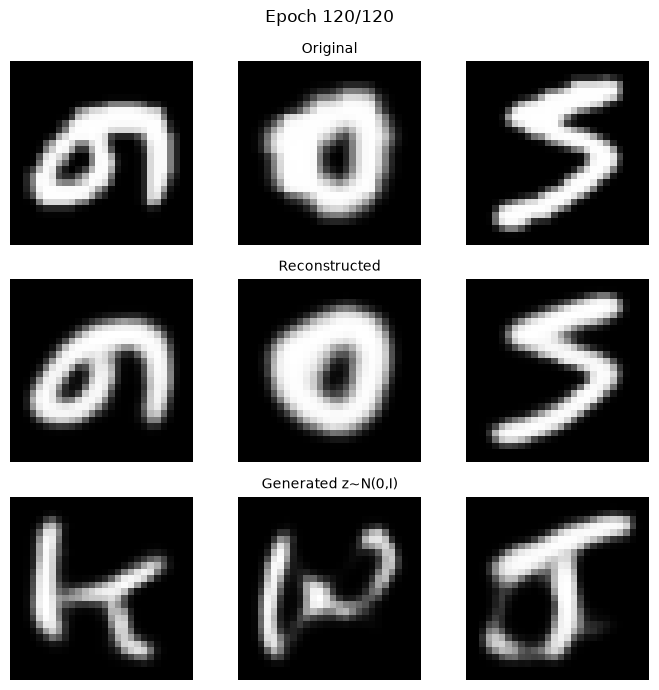

Training complete!
Best test loss: 136.8814  (saved as notebooks/training_checkpoints/vae_best.ckpt)


In [12]:

model, optimizer, start_epoch, best_test_loss, history = init_training()

epoch_list      = history['epoch_list']
train_loss_list = history['train_loss_list']
test_loss_list  = history['test_loss_list']

fixed_images, _ = next(iter(train_loader))
fixed_images = fixed_images[:3]

for epoch in range(start_epoch, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    test_loss  = evaluate(model, test_loader, device)

    epoch_list.append(epoch)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    print(f'Epoch [{epoch:03d}/{EPOCHS}]  '
          f'Train: {train_loss:.4f}  '
          f'Test: {test_loss:.4f}')

    # periodic checkpoint
    if epoch % CHECKPOINT_EVERY == 0 or epoch == EPOCHS:
        ckpt_path = os.path.join(CKPT_DIR, f'vae_epoch_{epoch:03d}.ckpt')
        save_checkpoint(ckpt_path, model, optimizer, epoch, train_loss, test_loss, history)
        prune_old_checkpoints(KEEP_LAST)
        print(f'  ↳ checkpoint saved: {ckpt_path}')


    # best model so far (survives a Colab disconnect)
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        save_checkpoint(os.path.join(CKPT_DIR, 'vae_best.ckpt'), model, optimizer, epoch, train_loss, test_loss, history)

    if epoch % 5 == 0 or epoch == 1:
        show_examples(model, fixed_images, epoch, device)

print('Training complete!')
print(f'Best test loss: {best_test_loss:.4f}  (saved as {CKPT_DIR}/vae_best.ckpt)')


## 10. Loss curve (for the presentation)

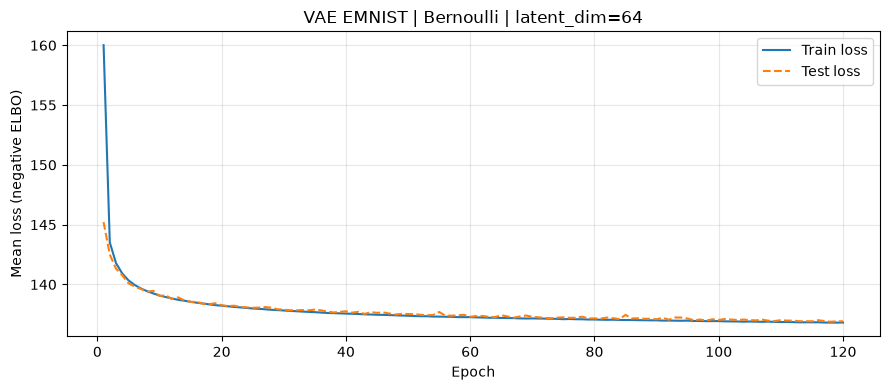

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(epoch_list, train_loss_list, label='Train loss')
plt.plot(epoch_list, test_loss_list,  label='Test loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Mean loss (negative ELBO)')
plt.title(f'VAE EMNIST | {RECONSTRUCTION} | latent_dim={LATENT_DIM}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vae_loss_curve.png', dpi=150)
plt.show()

## 11. 2D marginals of the latent space (for the presentation)

Projects all test set examples into the latent space
and plots scatter plots of pairs of dimensions colored by class.
This shows whether the VAE learned a good class-separated representation.

Loaded notebooks/training_checkpoints/vae_best.ckpt
  epoch      : 118
  train_loss : 136.8127
  test_loss  : 136.8814


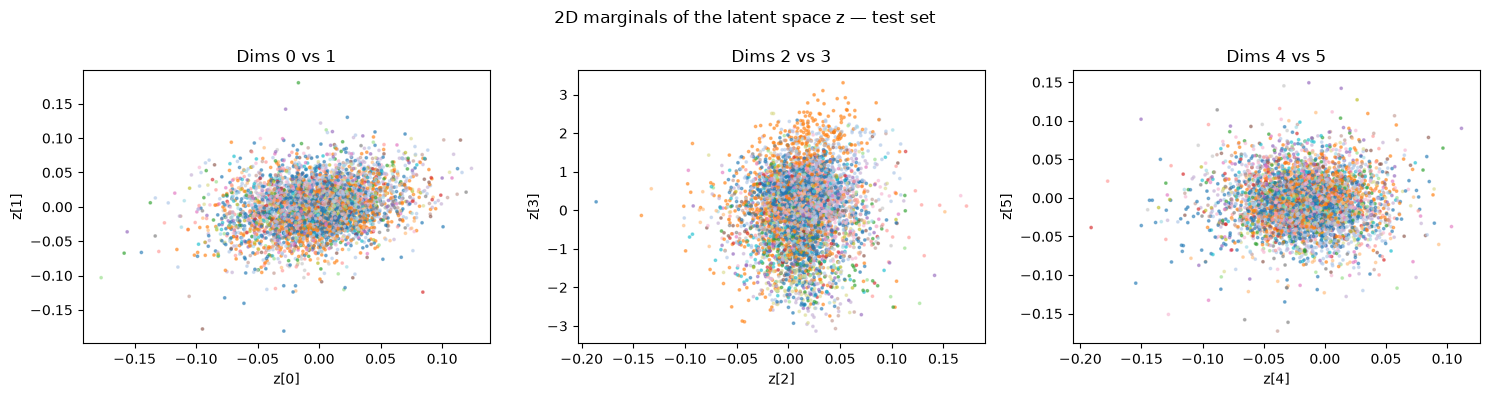

In [14]:
@torch.no_grad()
def plot_latent_marginals(model, loader, device, n_pairs=3, max_samples=5000):
    """
    Plots scatter plots of pairs of latent space dimensions.
    Each point is colored by the image class.
    """
    model.eval()
    all_z, all_labels = [], []

    for images, labels in loader:
        x = image_to_vec(images.to(device))
        z = model.encode(x)   # uses only mu, no noise
        all_z.append(z.cpu())
        all_labels.append(labels)
        if sum(len(b) for b in all_z) >= max_samples:
            break

    Z      = torch.cat(all_z)[:max_samples].numpy()
    labels = torch.cat(all_labels)[:max_samples].numpy()

    # plot n_pairs pairs of dimensions: (0,1), (2,3), (4,5)
    fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4))
    cmap = plt.get_cmap('tab20', 62)   # 62 classes in byclass

    for i, ax in enumerate(axes):
        d1, d2 = 2 * i, 2 * i + 1
        sc = ax.scatter(Z[:, d1], Z[:, d2],
                        c=labels, cmap=cmap,
                        s=3, alpha=0.5)
        ax.set_xlabel(f'z[{d1}]')
        ax.set_ylabel(f'z[{d2}]')
        ax.set_title(f'Dims {d1} vs {d2}')

    plt.suptitle('2D marginals of the latent space z — test set', fontsize=12)
    plt.tight_layout()
    plt.savefig('latent_marginals.png', dpi=150)
    plt.show()

# Prefer the best checkpoint; if it is missing, fall back to the in-memory model
if os.path.exists(os.path.join(CKPT_DIR, 'vae_best.ckpt')):
    plot_model, _ = load_checkpoint('vae_best.ckpt')
elif 'model' in globals():
    print('vae_best.ckpt not found — using the in-memory model from the last run.')
    plot_model = model
else:
    raise FileNotFoundError(
        'No vae_best.ckpt and no model in memory. '
        'Run the training cell first.'
    )

plot_latent_marginals(plot_model, test_loader, device)